Bu proje "California Housing Prices" (Kaliforniya Konut Fiyatları) projesidir. 

Senaryo: Bir emlak şirketinde yeni işe başlayan veri bilimcisin. 
Görev: Kaliforniya nüfus sayımı verilerini kullanarak, belirli bir bölgedeki (district) medyan konut fiyatını tahmin eden bir model kurman isteniyor. 
Neden? Şirket bu tahminleri kullanarak hangi bölgeye yatırım yapacağına karar verecek.


Mühendislik Kontrol Listesi (Checklist):

Hedef: Fiyat tahmini (Sayısal bir değer).

Öğrenme Türü: Denetimli (Supervised) (Çünkü elimizde geçmiş veriler ve onların etiketleri yani fiyatları var).

Görev Türü: Regresyon (Regression). (Daha spesifik olarak: Çok değişkenli regresyon).

Performans Ölçütü: RMSE (Root Mean Squared Error). Hataların karesini alıp toplar, kökünü alırız. Büyük hataları (outlier) çok fena 
cezalandırır.



"Toplu Öğrenme" Ne Demek?
Batch Learning (Toplu Öğrenme):

Tüm veriyi bir kez eğitmek
Yeni veri geldiğinde modeli yeniden eğitmek
Gerçek zamanlı güncelleme yapılmaz

Online Learning (Çevrimici Öğrenme):

Veri geldikçe modeli güncellemek
Örnek: Spam filtreleri, finans uygulamaları

İşletme Soruları
Teknik olarak başlamadan ÖNCE, yöneticiye şu soruları sormak gerekir:
Soru 1: Model ne için kullanılacak?

Yanıt: Gayrimenkul yatırım kararları almak için
"Bu mahallede yatırım yapmalı mıyız?" kararını vermek
Model, başka bir makine öğrenmesi sistemine girdi sağlayacak

Soru 2: Mevcut durum nasıl?

Yanıt: Şu an insan uzmanlar el ile tahmin yapıyor

Zaman alıcı ve maliyetli
Tahminler çoğu zaman hatalı (%30 civarında)
Veri bulunmadığında tamamen tahmine dayanıyor



Soru 3: Başarı kriteri nedir?

Yanıt: İnsan tahminleri yenmek

Uzmanların %30 hatalı olması → Biz daha az hata yapmalıyız





Bu Sorular Neden Önemli?
Cevaplar sizin şu kararlarınızı etkiler:
İş Amacı Belirleme
        
    Hangi Algoritma Seçeceğim? (Basit mi, Karmaşık mı?)
    
    Performans Ölçüsü Nedir? (RMSE? MAE?)
    
    Modelinizi Geliştirmeye Ne Kadar Zaman Harcamalı?
    
    Hangi Özelliklere Odaklanmalı?

 PERFORMANS ÖLÇÜSÜNÜ SEÇMEK
4.1 "Performans Ölçüsü" Nedir?
Model ne kadar iyi çalışıyor bunu ölçmek için bir metrik gerekir.
Benzetme: Sınava girdiniz

Model = Sizin cevaplarınız
Performans Ölçüsü = Puanlama sistemi
RMSE = Kaç soruyu yanlış yaptınız?

RMSE (Root Mean Squared Error)
Adı: Karekök Ortalama Kare Hata
Formül:
RMSE = √(1/n × Σ(ŷᵢ - yᵢ)²)

Parçalara ayıralım:
- yᵢ     = Gerçek konut fiyatı
- ŷᵢ     = Model tarafından tahmin edilen fiyat
- (ŷᵢ - yᵢ) = Hata
- (ŷᵢ - yᵢ)² = Hatanın karesi (kare almak büyük hataları cezalandırır)
- 1/n    = Ortalaması
- √      = Karekökü (sonucu anlaşılır hale getirir)
 Somut Bir Örnek
Diyelim 4 mahalle için tahmin yapıyoruz:
MahalleGerçek FiyatTahminHataHata²A300,000$320,000$-20,000$400,000,000B500,000$490,000$+10,000$100,000,000C400,000$380,000$+20,000$400,000,000D350,000$350,000$0$0
Hesaplama:

Hata² Ortalaması = (400M + 100M + 400M + 0) / 4 = 225,000,000


RMSE = √225,000,000 = 15,000$
Anlamı: Modelimiz ortalama olarak 15,000$ hata yapıyor


RMSE vs MAE (Diğer Ölçü)
MAE (Mean Absolute Error) - Ortalama Mutlak Hata:
MAE = 1/n × Σ|ŷᵢ - yᵢ|

Parçalara ayıralım:
- |ŷᵢ - yᵢ| = Hatanın mutlak değeri (kare almıyoruz)
Yukarıdaki örneğe geri dönersek:

MAE = (20,000 + 10,000 + 20,000 + 0) / 4 = 12,500$

Karşılaştırma:

RMSE = 15,000$  ← Büyük hatalara daha duyarlı

MAE  = 12,500$  ← Daha az hassas

Neden İkisini de Bilmek İyi?

RMSE: Büyük hataları cezalandırmak istiyorsan (çok önemli)

Örnek: Doktor hataları

MAE: Ortalama hatayı görmek istiyorsan (daha anlaşılır)

Örnek: Genel tahmin doğruluğu

Bizim Proje İçin: RMSE seçtik (çok pahalı hatalar cezalandırılsın)

Veriyi İçeri Alma (Get the Data)
İlk iş kütüphaneleri çağırmak ve veriyi yüklemektir.


In [34]:
import pandas as pd
import os
import tarfile
import urllib.request


def load_housing_data(housing_path="datasets/housing"):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()

Artık housing adında bir DataFrame'imiz var.

Pandas DataFrame Nedir?
Python'un veri işleme standardı. Tablo gibi çalışır

İlk Bakış (head())
Tablonun ilk 5 satırına bakalım

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Çıktı Analizi:

Sütunlar: longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, ocean_proximity.

Gözlem: ocean_proximity hariç hepsi sayısal. ocean_proximity metin (string) tabanlı.

longitude = Batı-Doğu konum
latitude = Kuzey-Güney konum
housing_median_age = Konutların yaş ortalaması
total_rooms = Toplam oda sayısı
vb.

Verinin Şekli

In [36]:
# Verinin boyutu
housing.shape
# Çıktı: (20640, 10)
# 20,640 satır (mahalle) ve 10 sütun (özellik)

(20640, 10)

In [4]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Sorun 1: Toplam 20,640 satır var ama total_bedrooms sütununda 20,433 veri var. Yani 207 satırda yatak odası bilgisi eksik (NaN). Bunu ileride temizlememiz lazım.

Not: ocean_proximity veri tipi object. Bu kategorik bir veri. Hemen içeriğine bakalım:

In [5]:
housing["ocean_proximity"].value_counts()


<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

Sonuç:
ISLAND: 5 Sadece 5 tane ada evi var, bu çok az. Model bunu öğrenmekte zorlanabilir.

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Analiz:

Standart sapma (std), min, max değerlerine bakarız.

Örneğin total_rooms max değeri 6445 iken min değeri 1. Çok büyük bir uçurum var. Ölçekleme (Scaling) şart.

Enlem ortalama 35.63 (California'nın güneyinde)
Konut yaşı ortalama 28.6 yıl
Oda sayısı çok değişken (2'den 39,320'ye kadar!)
vb.

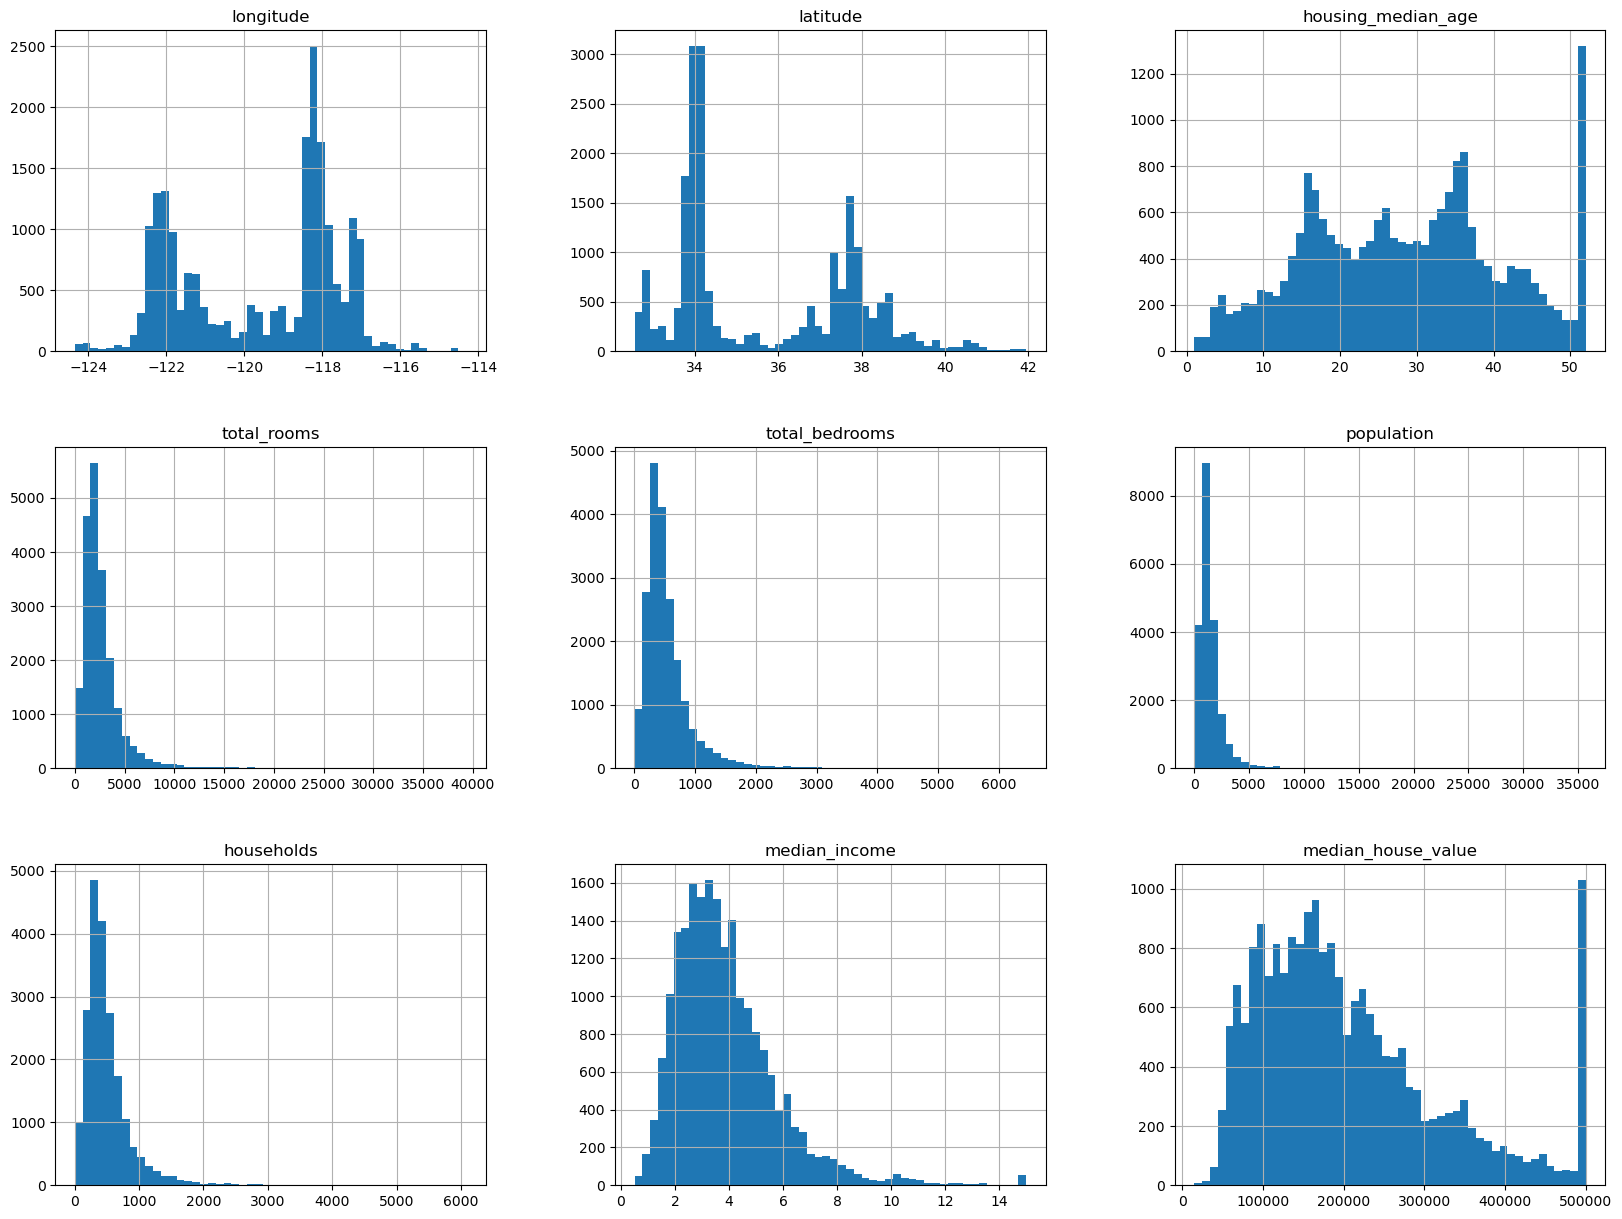

In [7]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

Burada 3 Kritik Sorun Görüyoruz:

Medyan Gelir (Median Income): Normal dolar değil (örn: 15.000$ değil, 1.5, 3.8 gibi sayılar). Veri ölçeklenmiş. (Sorun değil ama bilmek lazım).

Kuyruklar (Tail-Heavy): Grafikler sağa doğru uzamış (Çan eğrisi değil). Algoritmalar simetrik çan eğrisini (Gaussian) sever. Bunları düzeltmeliyiz.

Tavan Sınırı (Capping): median_house_value grafiğinde en sağda (500.000$) devasa bir çubuk var.

Anlamı: Sistemi kuranlar "500.000$' dan pahalı evleri  500.000$ olarak kaydet" demiş.

Risk: Modelin, evlerin 500k'dan pahalı olabileceğini asla öğrenemeyecek. Eğer patronun "Bana 1 Milyonluk evleri bul" derse, bu veriyle o işi yapamayız.

TEST SETİ OLUŞTURMAK - ÇOK ÖNEMLİ!
7.1 Neden Test Seti Lazım?
Senaryo: Sınava hazırlanıyorsunuz

Ders kitabındaki soruları çözüyorsunuz
Onları çok iyi öğreniyorsunuz
Sınav zamanı → Tamamen farklı soruların geldiğini görsünüz
Kapalı sınav!

Makine Öğrenmesi de aynı:

Modeli eğitim verisi (ders kitabı) ile eğitiyorsunuz
Modeli sadece eğitim verisi üzerinde test ederseniz
Model eğitim verisine "ezberlemis" hale gelir (overfitting)
Yeni veri geldiğinde kötü performans gösterir

7.2 Çözüm: Train-Test Split
Verinin %80'i ile eğit,
%20'si ile test et:
Tüm Veri (20,640 mahalle)
                                        
 (80%)                       
Eğitim Seti                   
(16,512 mahalle)              
                               
    (20%)
 Test Seti                    
(16,512 mahalle)  

Model Eğit  

Gerçek Performans Ölç

Yanlış Yol vs Doğru Yol
❌ YANLIŞ:

python#

Veriyi rastgele karıştır

housing_shuffled = housing_full.sample(frac=1)

# İlk %80'i eğitim, kalanı test yap

train_set = housing_shuffled[:16512]

test_set = housing_shuffled[16512:]

Problem: Eğitim ve test seti benzer dağılıma sahip

Fiyatların dağılımı aynı
Özeliklerin dağılımı aynı
Gerçek dünyada bu olmaz!

✅ DOĞRU:
pythonfrom sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing_full,
    test_size=0.2,        # %20'si test
    random_state=42       # Her çalıştırışta aynı sonuç
)

print(f"Eğitim seti: {len(train_set)}")  # 16512

print(f"Test seti: {len(test_set)}")    # 4128

7.4 Test Seti Nasıl Korunur?

Kural: Test seti ASLA eğitim sırasında görülmemelidir

Eğitim Döngüsü:
    Model Eğit (sadece train_set)
    
    Hiperparameter Ayarla (sadece train_set ile CV)
    
   Değerlendirme Yapma test_set'i GÖRMEDİN

Final Test (Sadece 1 kez):
    
    test_set üzerinde tahmin yap

Neden? Eğer siz test seti verilerini "kurtarırsanız" (meydana çıkarırsanız):

Parametreler test setine özel olacak
Gerçek performans göremezsiniz
Veri Sızıntısı (Data Leakage) denir



VERİYİ KEŞFETMEK VE GÖRSELLEŞTİRMEK

Keşif Sizi Şu Sorulara Cevap Bulmaya Yardım Eder:

Verinin dağılımı nasıl?
Hangi özellikler önemli?
Özellikler arasında bağlantı var mı?
Aykırı değerler var mı?
Eksik veriler nerede?

Veri Gözetleme Yanlılığı (Data Snooping Bias) yaşamamak için verinin %20'sini şimdi ayırıp kasaya kilitlemeliyiz.

Yanlış Yöntem: Rastgele Bölme
train_test_split ile rastgele bölebilirsin. Ama... Kaliforniya'da "Medyan Gelir" fiyatları belirleyen en önemli faktördür. Eğer rastgele bölerken şans eseri zengin bölgelerin hepsi test setine giderse, eğitim seti fakir kalır ve model yanlış öğrenir. Buna Örnekleme Gürültüsü (Sampling Bias) denir.

Gelir gruplarının oranını koruyarak bölmeliyiz.

In [8]:
import numpy as np
# Geliri kategorilere ayıralım (1.5 - 3.0 - 4.5 - 6.0 gibi)
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

Sonuç: Artık strat_train_set ve strat_test_set elimizde. Test setini bir kenara bırakıyoruz ve sadece strat_train_set ile çalışıyoruz.

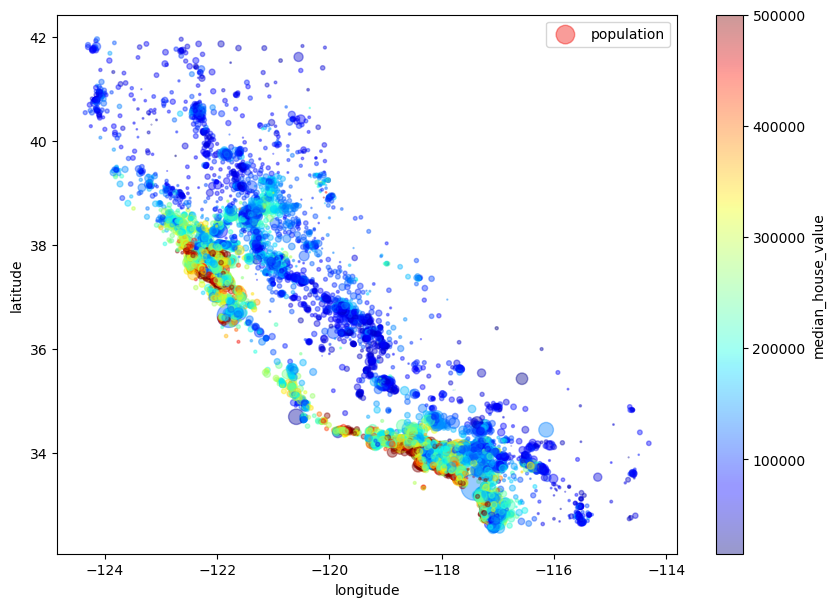

In [9]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10,7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()

Kodun Analizi:

x="longitude", y="latitude": Harita koordinatları.

alpha=0.4: Noktaları şeffaf yap ki yoğun yerler koyu görünsün.

s=...: Dairenin büyüklüğü Nüfusu gösterir.

c=...: Dairenin rengi Fiyatı gösterir (Kırmızı pahalı, Mavi ucuz).



Grafiğin En Batısı (Solda)    ← San Francisco (Pahalı - Kırmızı)
                                    
Ortası → Los Angeles (Pahalı)  ← Mavi Okyanus (Daha Pahalı)

İç Bölgeler (Mavi/Açık Renkler)  ← Ucuz

Çıkan İçgörü:Okyanustan Yakınlık Önemli! Deniz kenarındaki evler çok pahalı
Büyük Şehirler: SF ve LA etrafında yüksek fiyatlar
Nüfus Bağlantısı: Daire boyutu = Nüfus (daha kalabalık yerler)

In [10]:
corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

median_income (0.68): Çok güçlü pozitif ilişki. Gelir artarsa ev fiyatı artar.

latitude (-0.14): Negatif ilişki. Enlem arttıkça (kuzeye gittikçe) fiyat hafif düşüyor.

Var olan sütunlar yetersiz. Örneğin: total_rooms (toplam oda). Bir ilçede 10.000 oda olması bir şey ifade etmez. Eğer 5.000 hane varsa, ev başına 2 oda düşer. Bize Hane Başına Oda Sayısı lazım.

In [12]:
# 1. Özellik: Hane başına düşen oda sayısı
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]

# 2. Özellik: Toplam odaların ne kadarı yatak odası (Oran)
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

# 3. Özellik: Hane başına düşen nüfus (Evde kaç kişi yaşıyor?)
housing["population_per_household"] = housing["population"] / housing["households"]

In [13]:
corr_matrix = housing.corr()
# Fiyat ile olan ilişkiyi büyükten küçüğe sırala
print(corr_matrix["median_house_value"].sort_values(ascending=False))

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


Bu çıktıda çok kritik iki keşif var:

bedrooms_per_room (-0.25):

Bu, ham veri olan total_rooms (0.13) veya total_bedrooms (0.04) sütunlarından çok daha güçlü bir sinyaldir.

Anlamı: Sayı negatif olduğu için ters orantı var. Yani bir evde yatak odası oranı ne kadar düşükse, ev o kadar pahalı oluyor.

Mantığı: Genellikle lüks evlerde oda sayısı çoktur ama bunların çoğu salon, çalışma odası veya oyun odasıdır (yatak odası değildir). Yani yatak odası oranı düşüktür. Öğrenci evlerinde veya küçük dairelerde ise odaların çoğu yatak odasıdır.

rooms_per_household (+0.15):

Eski total_rooms (0.13) verisinden daha iyi bir sinyal.

Anlamı: Hane başına düşen oda sayısı arttıkça, evin fiyatı artıyor. (Daha büyük ev = Daha pahalı ev).

Ders: Sadece bu basit bölme işlemleriyle modelin başarısını artıracak çok değerli ipuçları (feature) yakaladık. Veri bilimi sadece algoritma seçmek değil, veriyi bu şekilde "konuşturmaktır".

Önce, elimizdeki eğitim setini Sorular (Features) ve Cevaplar (Labels) olarak ikiye ayıralım. Temizleme işlemini cevap anahtarına yapmamıza gerek yok.

In [14]:
housing = strat_train_set.drop("median_house_value", axis=1) # Sorular (Girdi)
housing_labels = strat_train_set["median_house_value"].copy() # Cevaplar (Hedef)

In [ ]:
Bölüm 2: Veriyi Hazırlama (Preprocessing)

1. EKSIK VERİLERLE BAŞA ÇIKMA
Hatırlıyorsunuz mu? Veriye baktığımızda total_bedrooms sütununda 207 tane eksik değer vardı.

1.1 Eksik Veriler Neden Sorun?
Çoğu makine öğrenmesi algoritması "boş" değerler işleyemez.

Örnek Veri:
Mahalle A: [4 oda, 2 yatak, ? nüfus, 300,000$]  ← Nüfus yok!

Model Eğitmeye Çalış:
? = Rakam değil, tam sayı değil
Model çöktü!

1.2 Eksik Verilerle İlgilenme Yolları

Yol 1: Satırı Silme
pythonhousing_clean = housing_full.dropna(subset=["total_bedrooms"])
# total_bedrooms eksik olan satırları sil

# Kaç satır silindi?
print(f"Eski boyut: {len(housing_full)}")      # 20640
print(f"Yeni boyut: {len(housing_clean)}")     # 20433
# 207 satır silindi

Avantajları:

Basit ve hızlı
Eksik veriden kurtulur

Dezavantajları:

Veri kaybı
Eğer eksik veriler dağılıysa problemli (örnek: %50 eksik)

Yol 2: Sütunu Silme
pythonhousing_no_feature = housing_full.drop("total_bedrooms", axis=1)
# total_bedrooms sütunun tamamını sil

print(housing_no_feature.shape)  # (20640, 9) - 10'dan 9'a düştü

Avantajları:

Veri kaybı yok

Dezavantajları:

Potansiyel önemli bilgi kaybı
Yatak odası sayısı fiyat tahmini için yararlı olabilir


Yol 3: Doldurma (İmpütasyon)
pythonfrom sklearn.impute import SimpleImputer

# Ortalama değer ile doldur
imputer = SimpleImputer(strategy="median")
# "median" = ortanca değeri kullan (0.25, 0.5, 0.75 de var)

# Sayısal özellikleri seç
housing_numeric = housing_full.select_dtypes(include=['float64', 'int64'])

# İmpüter'i eğit
imputer.fit(housing_numeric)

# Uygulan
housing_filled = imputer.transform(housing_numeric)

# Sonuç numpy dizisinden DataFrame'e çevir
housing_filled = pd.DataFrame(housing_filled, columns=housing_numeric.columns)

print(housing_filled.isnull().sum())  # Hiç eksik değer yok!
Avantajları:

Veri kaybı yok
Akıllı bir değer ile doldurur

Dezavantajları:

Doldurma yapay, gerçek değil
Mantıksız değerler oluşabilir



Stratejiler Seçmek
Bu Proje İçin:

total_bedrooms eksikliği: 207 / 20,640 = %1
Çok az! → Yol 3: İmpütasyon en iyisi

pythonimputer = SimpleImputer(strategy="median")
imputer.fit(housing_numeric)
housing_filled = imputer.transform(housing_numeric)

total_bedrooms sütununda bazı satırlar boştu. Çoğu Makine Öğrenmesi algoritması boşluklarla çalışamaz.

3 Seçeneğimiz Var:

Satırları sil: Eksik verisi olan bölgeleri at. (Veri kaybı olur).

Sütunu sil: total_bedrooms sütununu komple at. (Bilgi kaybı olur).

Doldur (Imputation): Boşlukları Ortalama (Mean), Medyan (Median) veya Sabit bir değerle (0) doldur.

Genellikle 3. Seçenek (Medyan ile doldurmak) en iyisidir. Çünkü medyan, uç değerlerden (aşırı zengin evler gibi) etkilenmez.

In [15]:
from sklearn.impute import SimpleImputer

# Strateji olarak medyan seçiyoruz
imputer = SimpleImputer(strategy="median")

# Medyan sadece sayılarla hesaplanır, metin (ocean_proximity) sütununu geçici olarak çıkaralım
housing_num = housing.drop("ocean_proximity", axis=1)

# 1. FIT: Verideki medyanları hesapla
imputer.fit(housing_num)

# 2. TRANSFORM: Hesapladığın medyanları boşluklara doldur
X = imputer.transform(housing_num)

# Sonuç Numpy dizisidir, tekrar DataFrame yapalım ki görelim
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)

imputer.statistics_ diyerek her sütunun medyanını görebilirsin. Bu değerleri saklamalıyız, çünkü canlı sistemde yeni veri geldiğinde de eksikleri bu değerlerle dolduracağız.

KATEGORİK ÖZELLİKLERİ İŞLEME
2.1 Kategorik Özellik Nedir?

Sayı olmayan, kategori/sınıf olan özellikler:
ocean_proximity Sütunu:
Değerler: <1H OCEAN, INLAND, ISLAND, NEAR OCEAN, NEAR BAY

Mahalle A: <1H OCEAN
Mahalle B: INLAND
Mahalle C: NEAR BAY
Modelimiz 0-1 arasında sayı bekliyor, ama bunlar metinler!

2.2 Kategorileri Saymak
pythonhousing_full["ocean_proximity"].value_counts()
Sonuç:
<1H OCEAN      9136  (çoğunluk)
INLAND         6551
NEAR BAY       2290
NEAR OCEAN     2124
ISLAND           5   (çok az)
Bilmemiz gereken: 5 farklı kategori


2.3 One-Hot Encoding (Seçkin Kodlama)
Fikir: Her kategoriyi ayrı sütun yapın
pythonfrom sklearn.preprocessing import OneHotEncoder

# OneHotEncoder oluştur
encoder = OneHotEncoder()

# ocean_proximity sütununu kodla
ocean_encoded = encoder.fit_transform(
    housing_full[["ocean_proximity"]]
).toarray()

print(ocean_encoded.shape)  # (20640, 5) - 5 kategori

print(ocean_encoded[:3])  # İlk 3 satırı gör
Sonuç:

Original:         One-Hot Encoded:

<1H OCEAN      →  [1, 0, 0, 0, 0]  ← <1H OCEAN sütunu = 1
INLAND         →  [0, 1, 0, 0, 0]  ← INLAND sütunu = 1
NEAR BAY       →  [0, 0, 1, 0, 0]  ← NEAR BAY sütunu = 1
NEAR OCEAN     →  [0, 0, 0, 1, 0]  ← NEAR OCEAN sütunu = 1
ISLAND         →  [0, 0, 0, 0, 1]  ← ISLAND sütunu = 1
Açıklama:

Her kategori için bir sütun
Eğer bu kategorideyse = 1, değilse = 0
Örnek: <1H OCEAN kategorisindeyse ilk sütun 1

2.4 Neden One-Hot Encoding?
Makine öğrenmesi modelleri sayıları matematiksel olarak işler.
Yanlış Yaklaşım:
<1H OCEAN   → 0
INLAND      → 1
NEAR OCEAN  → 2
NEAR BAY    → 3
ISLAND      → 4
Problem: Model bunu sıra olarak algılar!

ISLAND (4) > INLAND (1) gibi görünür
Ama ISLAND sahibinin evi INLAND sahibinden daha pahalı değil!
Yanlış ilişki kurulur

One-Hot Encoding Çözümü:

Kategoriler arasında hiyerarşi yok
0 ve 1 ile düzeltilmiş ilişki



Bilgisayarlar matematikten anlar, "NEAR OCEAN" yazısından anlamaz. Bu metinleri sayıya çevirmeliyiz.

ocean_proximity sütunumuzda şunlar var: <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY, ISLAND.

Yanlış Yöntem (Ordinal Encoding): Bunlara 0, 1, 2, 3, 4 numarası verelim.

Hata: Model zanneder ki 0 (1H OCEAN) ile 1 (INLAND) birbirine çok yakın. Oysa alakaları yok. Ama 0 ile 4 (ISLAND) çok uzak zanneder. Bu matematiksel bir hata yaratır.

Doğru Yöntem (One-Hot Encoding): Her kategori için yeni bir sütun açarız (Evet/Hayır mantığı).

Ev INLAND ise: [0, 1, 0, 0, 0]

Ev ISLAND ise: [0, 0, 0, 0, 1]

In [16]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()

# Hem öğren hem çevir
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

# Sonuç 'Seyrek Matris' (Sparse Matrix) olur. Yer kaplamasın diye sadece 1'leri tutar.
# Görmek için diziye çevirebiliriz:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Ölçek Sorunu
Modelimiz tüm özellikleri görecek. Ama ölçekleri farklı:
longitude:     -124 ile -114 arasında (range = 10)
latitude:      32 ile 42 arasında (range = 10)
population:    3 ile 35,682 arasında (range = 35,679!)
median_income: 0.5 ile 15 arasında (range = 14.5)



Ölçekleme Neden Önemli?
Bazı algoritmalara göre mesela:
    
Karar Ağacı: Ölçeklendirmeye gerek yok (kategorik karar verir)
population > 5000 ise → pahalı

Sinir Ağları, SVM: Ölçeklendirme ÇOK önemli!
Model bilinmezler arasında hızlı eğitmek istedi
Büyük sayılar (population) havaya uçar
Küçük sayılar (income) fark edilmez
Eğitim dengesiz


Standardizasyon (Z-Score Normalization)
Fikir: Her özelliği ortalaması 0, standart sapması 1 olacak şekilde dönüştür
pythonfrom sklearn.preprocessing import StandardScaler

# Scaler oluştur
scaler = StandardScaler()

# Eğitim verisini kullanarak öğren
scaler.fit(X_train)

# Dönüştür
X_train_scaled = scaler.transform(X_train)

# Test verisini (yeni) dönüştür
X_test_scaled = scaler.transform(X_test)
Matematiksel Formül:
X_scaled = (X - X_mean) / X_std

Örnek:
population = 10,000
mean = 1,000
std = 2,000

X_scaled = (10,000 - 1,000) / 2,000 = 4.5





In [ ]:
Ölçeklendirme Örneği

Eğitim verisinde:
    
Özellik   Minimum Ortalama  Maximum    Std Dev
longitude -124.35  -119.57  -114.31   2.00
population 3         1,425   35,682   1,132


Ölçeklendirme sonrasında:

longitude:  [-124.35 → -2.4]  ← -119.57 - 2*2.00
           [-119.57 →    0]  ← Ortalama = 0
           [-114.31 →  2.4]  ← -119.57 + 2*2.00

population: [3 → -1.26]       ← (3 - 1425) / 1132
           [1425 →    0]     ← (1425 - 1425) / 1132
           [35682 → 30.3]    ← (35682 - 1425) / 1132
        
Artık Her Özellik -3 ile +3 arasında!
Dengeli ve karşılaştırılabilir

 
Ölçeklendirme Kuralları
⚠️ ÇOK ÖNEMLİ: Eğitim seti ile öğren, hepsine uygula!
python# ✅ DOĞRU
scaler = StandardScaler()
scaler.fit(X_train)           # Sadece eğitim verinden öğren!
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)   # Aynı scaler'ı kullan!



# ❌ YANLIŞ
scaler = StandardScaler()
scaler.fit(X_train)
scaler.fit(X_test)            # Tekrar eğitme! Parametreleri değişti
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ❌ YANLIŞ (2)
scaler1 = StandardScaler()
scaler1.fit(X_train)
X_train_scaled = scaler1.transform(X_train)

scaler2 = StandardScaler()
scaler2.fit(X_test)           # Farklı scaler! Ölçek farklı!
X_test_scaled = scaler2.transform(X_test)

Neden? Eğer test seti ile farklı şekilde ölçeklendirilirse:

Test seti yapay bir şekilde dönüştürülür
Model bunu hiç görmedi
Performans ölçüsü yanlış




Burası Makine Öğrenmesi için hayati önem taşır. Veri setimizde iki sütun düşün:

total_rooms: 6 ile 39,320 arasında değişiyor.

median_income: 0 ile 15 arasında değişiyor.

Algoritmalar büyük sayıları "daha önemli" sanmaya meyillidir. Ayrıca sayı farkları çok büyükse (Gradient Descent gibi) optimizasyon algoritmaları çok yavaş çalışır.

Çözüm: Standardization (Standartlaştırma) Her değerden ortalamayı çıkarıp standart sapmaya böleriz. Böylece tüm veriler ortalama 0, sapma 1 olacak şekilde eşitlenir.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# scaler.fit_transform(housing_num)

Pipeline Nedir?
Birçok adımı birbiri ardından uygulamak:

Veri
  ↓
[Adım 1: İmpütasyon] ← Eksik değerleri doldur
  ↓
[Adım 2: Ölçeklendirme] ← Özellikleri normalleştir
  ↓
[Adım 3: Model Eğit] ← Makine öğrenmesi modeli eğit
  ↓
Tahmin

Pipeline Olmadan (Karışık)

# Adım 1: İmpütasyon
imputer = SimpleImputer(strategy="median")
X_train_filled = imputer.fit_transform(X_train)
X_test_filled = imputer.transform(X_test)

# Adım 2: Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

# Adım 3: Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Şu ana kadar 10 satır ve hatalara açık!


Problemler:

Uzun ve karmaşık
Adımları unumak kolay
Eğer adımlar yanlış sıradaysa hata

Pipeline ile (Temiz)

from sklearn.pipeline import Pipeline

# Pipeline oluştur
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Eğit ve tahmin yap
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Çok daha temiz!

Avantajları:

Kod kısa ve anlaşılır
Adımlar otomatik sırada
Veri sızıntısı riski azalır

 Pipeline Avantajlarının Özeti
 
 
Avantaj                               Açıklama


Temizlik                       Kod kısa ve okunması kolay

Hata Azaltma                   Adımları unumuş olur 

Veri SızıntısıÖnleme           Test verisi gizli kalır

Tekrar Kullanılabilir          Pipeline kaydedilebilir, yeniden yüklenebilir

Ölçeklenebilirlik              Büyük veri setlerine kolayca uygulanabilir

ColumnTransformer (Farklı Özelliklere Farklı İşlem)
Problem: Sayısal ve kategorik özellikler farklı işlem istiyorlar!

Sayısal Özellikler:       Kategorik Özellikler:
[longitude, latitude] → [İmpütasyon + Ölçeklendirme]
[total_rooms, ...]                  [ocean_proximity] → [One-Hot Encoding]

Çözüm: ColumnTransformer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sayısal özellikler için pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategorik özellikler için pipeline
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder())
])

# Birleştir
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Kullan
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Full pipeline
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

Yukarıdaki adımları (Doldur -> Özellik Ekle -> Ölçekle) tek tek elle yapmak hataya açıktır. Scikit-Learn'de Pipeline sınıfı ile bunları bir "üretim bandı"na dizeceğiz.

Ayrıca hem sayısal sütunları (imputer + scaler) hem kategorik sütunları (one-hot) aynı anda işlemek için ColumnTransformer kullanacağız. Bu, modern ML kodlamasının standardıdır.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# 1. Sayısal Sütunlar için Boru Hattı
num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),      # Eksikleri doldur
        # ('attribs_adder', CombinedAttributesAdder()),     # (İsteğe bağlı: Özellik mühendisliği sınıfı buraya eklenebilir)
        ('std_scaler', StandardScaler()),                   # Ölçekle
    ])

# 2. Genel Transformatör (Sayısal ve Kategorik Birleşimi)
num_attribs = list(housing_num)  # Sayısal sütun isimleri
cat_attribs = ["ocean_proximity"] # Kategorik sütun ismi

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),    # Sayısalları num_pipeline'a gönder
        ("cat", OneHotEncoder(), cat_attribs), # Kategorikleri OneHotEncoder'a gönder
    ])

# 3. Boru Hattını Çalıştır (Veriyi Hazırla)
housing_prepared = full_pipeline.fit_transform(housing)

Sonuç: housing_prepared değişkeni artık makine öğrenmesi algoritmalarına girmeye hazır, tertemiz, sayısal ve ölçeklenmiş bir matristir.

Altın Kural: fit() sadece Eğitim Setine yapılır. transform() ise hem eğitim, hem test, hem de canlı veriye yapılır.Test setindeki eksik veri eğitim setine göre doldurulur

1.Tutarlı API (Arayüz)
Scikit-Learn'in en güzel özelliği: Her şey aynı şekilde çalışır!

2.Fit-Transform Paradigması
Tüm transformatörlerin (dönüştürücülerin) aynı arayüzü var:

# 1. Nesne Oluştur
transformer = StandardScaler()

# 2. Fit et (eğitim verisi ile öğren)
transformer.fit(X_train)

# 3. Transform et (uygula)
X_train_transformed = transformer.transform(X_train)

# Veya birlikte:
X_train_transformed = transformer.fit_transform(X_train)

# 4. Yeni veri dönüştür (fit etme!)
X_test_transformed = transformer.transform(X_test)





3 Aynı Arayüz Örnekleri
Farklı dönüştürücüler ama aynı API:



# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# OneHotEncoder
encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(X)

# SimpleImputer
imputer = SimpleImputer(strategy="median")
X_filled = imputer.fit_transform(X)

# Hepsi fit-transform kullanır!






4 Modeller de Aynı

# Doğrusal Regresyon
model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)

# Karar Ağacı
model2 = DecisionTreeRegressor()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

# Rastgele Orman
model3 = RandomForestRegressor()
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

# Hepsi fit ve predict kullanır!




5.Bu Tasarımın Avantajları

Öğrenme Kolayı - Bir kez öğrendiniz mi, hepsini öğrendiniz
Kod Taşınabilir - Model değiştirmek kolay
Deneyleme Hızlı - Yeni algoritmaları hızlı deneyebilirsiniz


# Bir modelden diğerine geçmek
model = LinearRegression()    # Burayı değiştir
# model = DecisionTreeRegressor()
# model = RandomForestRegressor()

model.fit(X_train, y_train)   # Rest aynı kalır
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

1.Scikit-Learn'e Uyumlu Transformatör
Kendi transformatörünüzü yazabilirsiniz!


from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class RoomRatioAdder(BaseEstimator, TransformerMixin):
    """Haneye göre oda oranını ekle"""
    
    def __init__(self, add_bedroom_ratio=True):
        # Parametreler
        self.add_bedroom_ratio = add_bedroom_ratio
    
    def fit(self, X, y=None):
        # Eğitim verisinden öğren
        # (Bu durumda hiçbir şey öğrenmeye gerek yok)
        return self
    
    def transform(self, X):
        # Dönüştürmeyi yap
        X_copy = X.copy()
        
        # Yeni özellikler ekle
        X_copy["rooms_per_household"] = (
            X_copy["total_rooms"] / X_copy["households"]
        )
        
        if self.add_bedroom_ratio:
            X_copy["bedrooms_per_room"] = (
                X_copy["total_bedrooms"] / X_copy["total_rooms"]
            )
        
        return X_copy
        
        
2.Kullanımı
 
# Transformatörü oluştur
room_ratio_adder = RoomRatioAdder(add_bedroom_ratio=True)

# Kullan
X_train_with_ratios = room_ratio_adder.fit_transform(X_train)
X_test_with_ratios = room_ratio_adder.transform(X_test)

# Pipeline'a ekle
pipeline = Pipeline([
    ("room_ratios", RoomRatioAdder()),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])



Transformatör Gereksinimleri

Scikit-Learn'e uyumlu olması için:

1.BaseEstimator'dan Miras Al

get_params() ve set_params() otomatik


2.TransformerMixin'dan Miras Al

fit_transform() otomatik
fit() ve transform()'i sen yazıyorsun


3.fit() Metodunu Yaz

def fit(self, X, y=None):
       return self
       
4.transform() Metodunu Yaz

def transform(self, X):
       # Dönüştürme mantığı
       return X_transformed



Üç farklı modeli (Linear, Decision Tree, Random Forest) yarıştıracağız.

In [22]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
# Modeli eğit (Sadece temizlenmiş eğitim verisiyle)
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [23]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data) # Dikkat: Sadece transform!

print("Tahminler:", lin_reg.predict(some_data_prepared))
print("Gerçekler:", list(some_labels))

Tahminler: [271155.13266195 343762.54996648 117315.6147172  106562.52543797
 308334.73424246]
Gerçekler: [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

68096.66386988199


Sonuç: 68,096 Yorum: Ev fiyatlarında ortalama 68 bin dolar hata yapıyoruz. Evlerin çoğu 120-260 bin dolar arasıyken bu çok büyük bir hata. Model Underfit oldu (Veriyi öğrenemedi, yetersiz kaldı).

In [25]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

# Hatayı tekrar ölç
housing_predictions = tree_reg.predict(housing_prepared)
tree_rmse = np.sqrt(mean_squared_error(housing_labels, housing_predictions))
print(tree_rmse)

0.0


Sonuç: 0.0 Yorum: Hata sıfır mı bu imkansız model soruları ezberledi. Buna Overfitting (Aşırı Uyum) denir. Bunu kanıtlamak için test setine dokunmadan doğrulama yapmamız lazım.

ÇAPRAZ DOĞRULAMA (CROSS-VALIDATION)


Çapraz Doğrulama Nedir?
Eğitim verisi üzerinde test etmeyin! Yanılsınız.
Çözüm: Eğitim verisini parçalara böl

Eğitim Verisi (16,512 mahalle)
        ↓
    ┌───────────────────────────────────┐
    │ Parça 1 │ Parça 2 │ Parça 3 │ ...
    └───────────────────────────────────┘

Döngü 1: [Test] [Eğit] [Eğit] ... → Performans Ölçü 1
Döngü 2: [Eğit] [Test] [Eğit] ... → Performans Ölçü 2
Döngü 3: [Eğit] [Eğit] [Test] ... → Performans Ölçü 3

Ortalama Performans = (Ölçü1 + Ölçü2 + Ölçü3) / 3



Neden K-Fold Doğrulama Kullanıyoruz?

Eğitim Verisi Üzerinde Test:
Sınavdan 1 gün önce → 100% (Ezberlediniz)
Gerçek Sınavda → 20% (Yeni sorular)
Güvenilmez!

K-Fold Çapraz Doğrulama:
Hiç görmediği verilerde → Ortalama 47% (Gerçekçi)
Tutarlı → Her döngüde benzer sonuçlar
Güvenilir!

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [67745.15380522 66888.78440532 66695.77956506 71823.10001737
 68613.09056422 68116.82825749 68498.95838522 69582.84657454
 67725.83939159 67909.56894376]
Mean: 68359.99499097781
Standard deviation: 1398.1452312543274


Sonuçlar:

Decision Tree Hatası: 71,407

Linear Regression Hatası: 68,360

Şok: Karar ağacı (Decision Tree), en basit Lineer modelden bile DAHA KÖTÜ çalışıyor! Çünkü ezberliyor, genelleme yapamıyor.

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Modeli Tanımla
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Modeli Eğit (Fit)
forest_reg.fit(housing_prepared, housing_labels)

# 3. Çapraz Doğrulama ile Test Et (Cross Validation)
# (Veriyi 10'a bölüp 10 kere dener)
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)

# 4. Hata Puanlarını Karekök (RMSE) Cinsine Çevir
forest_rmse_scores = np.sqrt(-forest_scores)

# 5. Sonuçları Ekrana Bas
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(forest_rmse_scores)

Scores: [48533.91917508 50029.4844434  47589.09745904 49348.08439953
 48322.58855615 49049.25586889 48290.96232432 49280.1807855
 48895.2753828  49390.97721244]
Mean: 48872.98256071495
Standard deviation: 665.8770542737867


Linear Regression: ~68.360$ Hata

Random Forest Sonucu: ~48.872 $ Hata

Arada 18.000$ fark var! Bu çok büyük bir iyileşme.

Sebebi: Linear Regression, veriye "dümdüz bir çizgi" çekmeye çalışıyordu. Ama Random Forest, verideki karmaşık, eğri büğrü ilişkileri (non-linear) yakalayabildi.

Şimdi bu 48.872 $ hatayı daha da düşürmek için ince ayar (Fine-Tuning) yapmamız gerekecek.

Modellerin Karşılaştırması



Model             -----          Hız          ---      Karmaşıklık  ---    Başarı

Doğrusal Regresyon  ----      ⚡⚡⚡ Çok hızlı -----       Çok basit-------       Başlangıçta iyi

Karar Ağacı  ---------             ⚡⚡ Hızlı   -----          Orta  ------          İyi overfitting riski 

Rastgele Orman ---------          ⚡   Yavaş  ------            Karmaşık ------       Çoğunlukla en iyi



MODEL                ORTALAMA HATA (RMSE)      STANDART SAPMA 
Linear Regression    $68,183 (±926)         
Decision Tree        $68,803 (±2114)        
Random Forest        $48,873 (±665)         


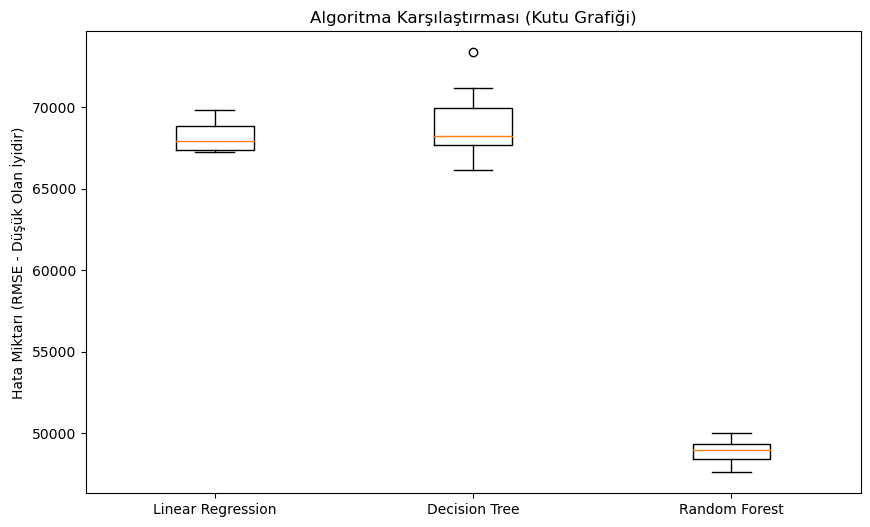

In [76]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# --- 1. DÖVÜŞÇÜLERİ TANIMLA ---
models = [
    ('Linear Regression', LinearRegression()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42))
]

results = []
names = []

print(f"{'MODEL':<20} {'ORTALAMA HATA (RMSE)':<25} {'STANDART SAPMA':<15}")
print("="*60)

# --- 2. RİNG (DÖNGÜ) ---
for name, model in models:
    # Cross Validation (10 Parçalı)
    # scoring="neg_mean_squared_error": Scikit-Learn hataları negatif tutar (büyük olan iyidir mantığı)
    scores = cross_val_score(model, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
    
    # Hatayı pozitife çevir ve karekök al (RMSE)
    rmse_scores = np.sqrt(-scores)
    
    # Sonuçları kaydet
    results.append(rmse_scores)
    names.append(name)
    
    # Ekrana Yazdır
    print(f"{name:<20} ${rmse_scores.mean():,.0f} {'(±' + str(int(rmse_scores.std())) + ')':<15}")

# --- 3. GÖRSELLEŞTİRME (BONUS) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names)
plt.title('Algoritma Karşılaştırması (Kutu Grafiği)')
plt.ylabel('Hata Miktarı (RMSE - Düşük Olan İyidir)')
plt.show()

Random Forest'ın en iyi model olduğuna karar verdik (Hatası ~49k). Ama işimiz bitmedi. Bu modelin fabrika ayarlarını (default parameters) kullandık. Şimdi bu ayarları kurcalayarak modelin performansını maksimize edeceğiz.

Buna Hyperparameter Tuning (Hiperparametre Ayarlaması) denir.

Modelin İnce Ayarı (Fine-Tuning)
Random Forest'ın içinde n_estimators (ağaç sayısı) veya max_features (her düğümde bakılacak özellik sayısı) gibi ayarlar vardır. Bunları tek tek elle denemek günler sürer.

Bunun yerine Grid Search (Izgara Araması) kullanacağız. Biz bilgisayara bir liste vereceğiz, o bütün kombinasyonları deneyip bize "En iyi ayar şudur" diyecek.

In [ ]:
HİPERPARAMETRE AYARLAMA (HYPERPARAMETER TUNING)

Parametre: Model tarafından EĞİTİM sırasında öğrenilen

Doğrusal Regresyon: w (ağırlık değerleri)
w = [3.5, -2.1, 0.8, ...]


Hiperparametre: SATTE SİZİN seçtiğiniz

Karar Ağacı:
- max_depth = 10 (ağacın derinliği)
- min_samples_split = 5 (bölüm için minimum örnekler)

Rastgele Orman:
- n_estimators = 100 (kaç tane ağaç)
- max_features = 5 (kaç özellik)

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Denenesecek hiperparametreler
param_grid = {
    'n_estimators': [10, 30, 100, 200],      # 4 seçenek
    'max_features': [2, 4, 8, "sqrt"],       # 4 seçenek
    'max_depth': [None, 5, 10, 20],          # 4 seçenek
    'min_samples_split': [2, 5, 10]          # 3 seçenek
}

# Total = 4 × 4 × 4 × 3 = 192 kombinasyon!

# Grid Search oluştur
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,                        # 5-Fold CV her kombinasyon için
    scoring='neg_mean_squared_error',
    n_jobs=-1                    # Tüm işlemci çekirdeklerini kullan
)

# Çalıştır
grid_search.fit(housing_prepared,housing_labels)

# En iyi parametreleri gör
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi CV RMSE: ${np.sqrt(-grid_search.best_score_):,.0f}")

# En iyi modeli al
best_model = grid_search.best_estimator_

En iyi parametreler: {'max_depth': None, 'max_features': 8, 'min_samples_split': 2, 'n_estimators': 200}
En iyi CV RMSE: $49,644


In [78]:
grid_search.best_params_

{'max_depth': None,
 'max_features': 8,
 'min_samples_split': 2,
 'n_estimators': 200}

In [47]:
import numpy as np
negative_mse = grid_search.best_score_
rmse = np.sqrt(-negative_mse)
print(rmse)

49644.354226699434


In [83]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 1. Parametre Dağılımını Tanımla (Liste değil, Aralık veriyoruz!)
param_distribs = {
    # n_estimators: 1 ile 200 arasında rastgele bir tamsayı seç
    'n_estimators': randint(low=1, high=200),
    
    # max_features: 1 ile 8 arasında rastgele bir tamsayı seç
    'max_features': randint(low=1, high=8),
}

forest_reg = RandomForestRegressor(random_state=42)

# 2. Random Search'ü Başlat
# n_iter=10: Toplam 10 farklı kombinasyon dene (Bunu artırabilirsin)
# cv=5: Her denemeyi 5 parçalı cross-validation ile yap
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)

# 3. Eğitimi Başlat ⏳
rnd_search.fit(housing_prepared, housing_labels)

# --- SONUÇLAR ---
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

print("\n🏆 Random Search'ün Bulduğu En İyi Ayarlar:", rnd_search.best_params_)
print(f"📉 En İyi Hata (RMSE): ${np.sqrt(-rnd_search.best_score_):,.0f}")

49692.28739145952 {'max_features': 7, 'n_estimators': 180}
51973.36763085786 {'max_features': 5, 'n_estimators': 15}
51164.60644990216 {'max_features': 3, 'n_estimators': 72}
51552.518936552595 {'max_features': 5, 'n_estimators': 21}
49777.491515202884 {'max_features': 7, 'n_estimators': 122}
51220.99066789822 {'max_features': 3, 'n_estimators': 75}
51147.0267907021 {'max_features': 3, 'n_estimators': 88}
50207.161556064115 {'max_features': 5, 'n_estimators': 100}
51109.03822654321 {'max_features': 3, 'n_estimators': 150}
66402.5116958865 {'max_features': 5, 'n_estimators': 2}

🏆 Random Search'ün Bulduğu En İyi Ayarlar: {'max_features': 7, 'n_estimators': 180}
📉 En İyi Hata (RMSE): $49,692


3.Hız Karşılaştırması:

Grid Search:    960 model (192 × 5) → 1-2 saat
Randomized:     100 model (20 × 5)  → 5-10 dakika

Grid Search daha kapsamlı, ama Randomized çoğunlukla yeterli.

In [84]:
# Grid Search sonuçlarını DataFrame'e çevir
results = pd.DataFrame(grid_search.cv_results_)

# En iyi 5 kombinasyonu gör
print(results[['param_n_estimators', 'param_max_depth', 'mean_test_score']].head())

  param_n_estimators param_max_depth  mean_test_score
0                 10            None    -3.136839e+09
1                 30            None    -2.802694e+09
2                100            None    -2.740890e+09
3                200            None    -2.730417e+09
4                 10            None    -3.089511e+09


1.Ensemble (İnsiyatif) Nedir?
Fikir: Birçok modeli birleştir, oy yaptır
Benzetme: Bir heyetin karar vermesi

Doktor A: "Yatış gerekli"
Doktor B: "Ilaç gerekli"
Doktor C: "İstirahat yeterli"
Karar: Çoğunluk → Yatış

Modeller eğitiliyor ve Çapraz Doğrulama (CV) yapılıyor... Lütfen bekleyin ⏳

🏆 Ensemble Model RMSE: $64,500


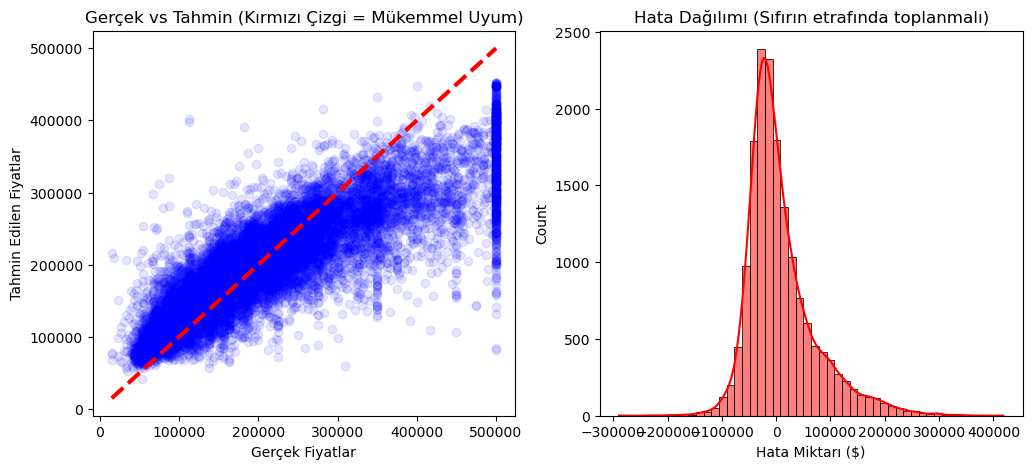


😱 En Büyük 5 Hata:
Index 5985: Gerçek=$450,000, Tahmin=$106,077, Fark=$343,923
Index 468: Gerçek=$500,001, Tahmin=$141,546, Fark=$358,455
Index 16487: Gerçek=$500,001, Tahmin=$131,467, Fark=$368,534
Index 2746: Gerçek=$500,001, Tahmin=$84,023, Fark=$415,978
Index 7217: Gerçek=$500,001, Tahmin=$81,843, Fark=$418,158


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict

# --- 1. MODELLERİ TANIMLA ---
# Not: SVR büyük veride yavaş çalışabilir, sabırlı ol veya veri setini küçült.
voting_reg = VotingRegressor([
    ('lr', LinearRegression()),
    ('tree', DecisionTreeRegressor(max_depth=10, random_state=42)), # Depth'i biraz kıstım, 15 çok ezberler
    ('svr', SVR(kernel='rbf', C=100))
])

print("Modeller eğitiliyor ve Çapraz Doğrulama (CV) yapılıyor... Lütfen bekleyin ⏳")

# --- 2. TAHMİN (CROSS VALIDATION İLE) ---
# DİKKAT: fit() yerine cross_val_predict kullanıyoruz.
# Bu fonksiyon veriyi 10'a böler, her parçayı "hiç görmediği" modelle tahmin eder.
y_pred = cross_val_predict(voting_reg, housing_prepared, housing_labels, cv=5)

# --- 3. HATA HESAPLAMA ---
final_mse = mean_squared_error(housing_labels, y_pred)
final_rmse = np.sqrt(final_mse)
print(f"\n🏆 Ensemble Model RMSE: ${final_rmse:,.0f}")

# --- 4. GÖRSEL HATA ANALİZİ (Dedektiflik Kısmı) ---
plt.figure(figsize=(12, 5))

# Grafik A: Gerçek vs Tahmin (Ne kadar düz çizgi o kadar iyi)
plt.subplot(1, 2, 1)
plt.scatter(housing_labels, y_pred, alpha=0.1, color="blue")
plt.plot([housing_labels.min(), housing_labels.max()], [housing_labels.min(), housing_labels.max()], 'r--', lw=3)
plt.xlabel("Gerçek Fiyatlar")
plt.ylabel("Tahmin Edilen Fiyatlar")
plt.title("Gerçek vs Tahmin (Kırmızı Çizgi = Mükemmel Uyum)")

# Grafik B: Hataların Dağılımı (Residuals)
plt.subplot(1, 2, 2)
errors = housing_labels - y_pred
sns.histplot(errors, bins=50, kde=True, color="red")
plt.xlabel("Hata Miktarı ($)")
plt.title("Hata Dağılımı (Sıfırın etrafında toplanmalı)")

plt.show()

# --- 5. EN BÜYÜK HATALAR NEREDE? ---
# En çok yanıldığımız 5 evi görelim
worst_indices = np.abs(errors).argsort()[-5:] # En büyük 5 hatanın indeksi
print("\n😱 En Büyük 5 Hata:")
for index in worst_indices:
    gercek = housing_labels.iloc[index]
    tahmin = y_pred[index]
    fark = gercek - tahmin
    print(f"Index {index}: Gerçek=${gercek:,.0f}, Tahmin=${tahmin:,.0f}, Fark=${fark:,.0f}")

🚀 Yıldızlar Karması eğitiliyor ve Tahmin yapılıyor... (Bu işlem SVR yüzünden 1-2 dk sürebilir) ⏳

🏆 GÜÇLENDİRİLMİŞ Ensemble RMSE: $54,529


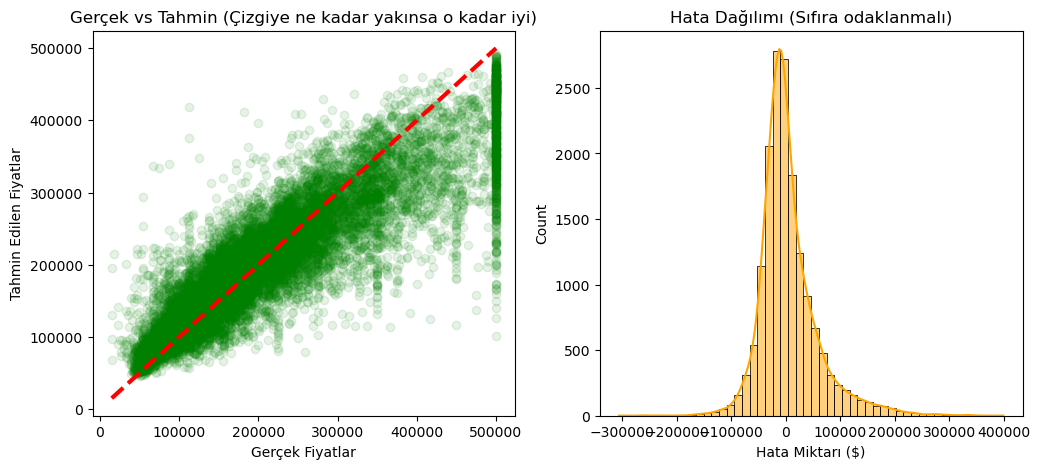


😱 Hâlâ Çözülemeyen En Büyük 5 Hata:
Index 13063: Gerçek=$500,001, Tahmin=$159,383, Fark=$340,618
Index 7555: Gerçek=$500,001, Tahmin=$149,724, Fark=$350,277
Index 468: Gerçek=$500,001, Tahmin=$140,244, Fark=$359,757
Index 16487: Gerçek=$500,001, Tahmin=$125,926, Fark=$374,075
Index 2746: Gerçek=$500,001, Tahmin=$101,202, Fark=$398,799


In [87]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict

# --- 1. MODELLERİ TANIMLA (YILDIZLAR KARMASI ⭐) ---
# Zayıf modelleri (Linear, Tree) attık. Yerine Şampiyonları aldık.
voting_reg = VotingRegressor([
    # Şampiyon 1: Rastgele Orman (Daha önce 49k yapmıştı)
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    
    # Şampiyon 2: Gradient Boosting (Hataları düzelterek ilerler, çok güçlüdür)
    ('gb', GradientBoostingRegressor(random_state=42)),
    
    # Yardımcı Oyuncu: SVR (Farklı bir bakış açısı katsın diye tuttuk)
    # Not: SVR yavaş çalışabilir, sabırla bekle ⏳
    ('svr', SVR(kernel='rbf', C=1000)) # C'yi artırdık ki daha agresif olsun
])

print("🚀 Yıldızlar Karması eğitiliyor ve Tahmin yapılıyor... (Bu işlem SVR yüzünden 1-2 dk sürebilir) ⏳")

# --- 2. TAHMİN (CROSS VALIDATION İLE) ---
# Modelin hiç görmediği veriler üzerindeki performansını simüle ediyoruz
y_pred = cross_val_predict(voting_reg, housing_prepared, housing_labels, cv=5)

# --- 3. HATA HESAPLAMA ---
final_mse = mean_squared_error(housing_labels, y_pred)
final_rmse = np.sqrt(final_mse)
print(f"\n🏆 GÜÇLENDİRİLMİŞ Ensemble RMSE: ${final_rmse:,.0f}")

# --- 4. GÖRSEL HATA ANALİZİ ---
plt.figure(figsize=(12, 5))

# Grafik A: Gerçek vs Tahmin
plt.subplot(1, 2, 1)
plt.scatter(housing_labels, y_pred, alpha=0.1, color="green") # Renk Yeşil olsun (Başarı rengi)
plt.plot([housing_labels.min(), housing_labels.max()], [housing_labels.min(), housing_labels.max()], 'r--', lw=3)
plt.xlabel("Gerçek Fiyatlar")
plt.ylabel("Tahmin Edilen Fiyatlar")
plt.title("Gerçek vs Tahmin (Çizgiye ne kadar yakınsa o kadar iyi)")

# Grafik B: Hata Dağılımı
plt.subplot(1, 2, 2)
errors = housing_labels - y_pred
sns.histplot(errors, bins=50, kde=True, color="orange")
plt.xlabel("Hata Miktarı ($)")
plt.title("Hata Dağılımı (Sıfıra odaklanmalı)")

plt.show()

# --- 5. EN BÜYÜK HATALAR ---
worst_indices = np.abs(errors).argsort()[-5:]
print("\n😱 Hâlâ Çözülemeyen En Büyük 5 Hata:")
for index in worst_indices:
    gercek = housing_labels.iloc[index]
    tahmin = y_pred[index]
    fark = gercek - tahmin
    print(f"Index {index}: Gerçek=${gercek:,.0f}, Tahmin=${tahmin:,.0f}, Fark=${fark:,.0f}")

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy import stats

# --- 1. ŞAMPİYON MODELİ HAZIRLA ---
# Grid Search'ten bulduğun en iyi ayarlar:
final_model = RandomForestRegressor(
    n_estimators=200,     # 200 Ağaç
    max_features=8,       # 8 Özellik
    random_state=42
)

print("🏆 Şampiyon Model (Random Forest) tüm eğitim verisiyle son kez eğitiliyor... ⏳")
final_model.fit(housing_prepared, housing_labels)

# --- 2. TEST SETİNİ HAZIRLA (SINAV KAĞITLARI) ---
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# DİKKAT: Sadece transform!
X_test_prepared = full_pipeline.transform(X_test)

# --- 3. BÜYÜK AN: TAHMİN ---
final_predictions = final_model.predict(X_test_prepared)

# --- 4. SONUÇLARI HESAPLA ---
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

# --- 5. GÜVEN ARALIĞI (%95) ---
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
mean = squared_errors.mean()
m = len(squared_errors)

interval = np.sqrt(stats.t.interval(confidence, m - 1,
                         loc=mean,
                         scale=stats.sem(squared_errors)))

print("\n" + "="*50)
print(f"🏁 FİNAL PROJE SONUCU (TEST SET RMSE): ${final_rmse:,.2f}")
print(f"📊 %95 Güven Aralığı: ${interval[0]:,.2f} - ${interval[1]:,.2f}")
print("="*50)

🏆 Şampiyon Model (Random Forest) tüm eğitim verisiyle son kez eğitiliyor... ⏳

🏁 FİNAL PROJE SONUCU (TEST SET RMSE): $49,798.40
📊 %95 Güven Aralığı: $47,380.74 - $52,104.01


In [55]:
from sklearn.ensemble import RandomForestRegressor

# Şu anda tüm bu ağaçları birleştiriyor
rf = RandomForestRegressor(n_estimators=100)
# 100 ağaç → Birleştir → Tahmin

1.Öznitelik Önemliği (Feature Importance)

Random Forest, "Hangi özellikler en önemli?" sorusuna cevap verebilir

In [73]:
# 1. En iyi modelin (Grid Search'ün bulduğu) özellik önemlerini alalım
feature_importances = grid_search.best_estimator_.feature_importances_

# 2. Bu önemleri özellik isimleriyle eşleştirelim
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs

# 3. Büyükten küçüğe sıralayıp yazdıralım
sorted(zip(feature_importances, attributes), reverse=True)

[(0.36223056324694736, 'median_income'),
 (0.1304508290243338, 'pop_per_hhold'),
 (0.11457809485030915, 'income_cat'),
 (0.10541021205665918, 'longitude'),
 (0.09509246457838205, 'latitude'),
 (0.05135627087437661, 'housing_median_age'),
 (0.038027770988172394, 'population'),
 (0.029814515981288307, 'total_rooms'),
 (0.0286422033686696, 'total_bedrooms'),
 (0.025534532835030693, 'households'),
 (0.008624745113447869, 'rooms_per_hhold'),
 (0.006892566314721361, 'INLAND'),
 (0.0030546972445322177, '<1H OCEAN'),
 (0.0002905335231295122, 'bedrooms_per_room')]

In [89]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Modeli Seç
final_model = voting_reg

# --- 🛠️ DÜZELTME BURADA: EĞİTİM (FIT) ---
# Modeli test setine sokmadan önce, tüm eğitim verisiyle eğitmeliyiz!
# cross_val_predict bunu yapmaz, o sadece test eder.
print("Model tüm eğitim verisiyle eğitiliyor (Fitting)... Lütfen bekleyin ⏳")
final_model.fit(housing_prepared, housing_labels)
# ----------------------------------------

# 2. Test Setini Hazırla
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

# 3. Test Setini Dönüştür (Sadece transform!)
X_test_prepared = full_pipeline.transform(X_test)

# 4. Büyük An: Tahmin Yap
# Artık hata vermez çünkü yukarıda .fit() yaptık
final_predictions = final_model.predict(X_test_prepared)

# 5. Sonucu Hesapla
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print(f"🏁 FİNAL TEST SONUCU (RMSE): ${final_rmse:,.2f}")

Model tüm eğitim verisiyle eğitiliyor (Fitting)... Lütfen bekleyin ⏳
🏁 FİNAL TEST SONUCU (RMSE): $54,270.47
